# Plant Leaf Disease Detection and Classification Using Image Processing Techniques
**Group 38** · Domain: Agriculture / Computer Vision

This notebook implements the full pipeline end to end:

1. Setup
2. Dataset exploration (PlantVillage, 38 classes)
3. Image preprocessing: resizing, CLAHE contrast enhancement, denoising, HSV disease segmentation
4. Stratified split, `tf.data` pipeline and augmentation
5. Model: EfficientNetB2 transfer learning with a custom head
6. Training (frozen base, then fine-tuning)
7. Evaluation on a held-out test set
8. Predictions and Grad-CAM explanations
9. Ablation: with vs. without CLAHE + denoising
10. Saving the model and a results summary

Every figure is also saved as a PNG in `outputs/`.

## 1. Setup

Imports, global configuration and random seeds (Python, NumPy and TensorFlow) for reproducibility.

**`SUBSET`** controls how much data is used. Training EfficientNetB2 on all ~54k images is only practical on a GPU,
so when no GPU is available we take a **stratified subset of `SUBSET` images per class** (every class keeps the same
number of images). Set `SUBSET = None` to use the full dataset.

In [1]:
SUBSET = 150   # images per class (stratified). Set to None to train on the full dataset.

import os, sys, random, time, json, platform
from pathlib import Path

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

SEED = 42
IMG_SIZE = 260                      # EfficientNetB2 native input resolution
DATA_DIR = Path('data/PlantVillage-Dataset/raw/color')
OUT_DIR = Path('outputs'); OUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('models'); MODEL_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)   # seeds Python, NumPy and TF

gpus = tf.config.list_physical_devices('GPU')
print('Python      :', platform.python_version(), '|', sys.executable)
print('TensorFlow  :', tf.__version__)
print('Keras       :', tf.keras.__version__ if hasattr(tf.keras, '__version__') else 'n/a')
print('OpenCV      :', cv2.__version__)
print('CPU cores   :', os.cpu_count())
print('GPU present :', bool(gpus), gpus)
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU found. SUBSET = {SUBSET} (set SUBSET = None to use the full dataset).')
else:
    print(f'No GPU detected: running on CPU only. Using a stratified subset of {SUBSET} images per class.')

I0000 00:00:1791344508.768367   26856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791344508.768953   26856 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1791344509.671924   26856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791344509.672255   26856 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Python      : 3.10.12 | /home/adityachavali/Group_38/venv/bin/python3
TensorFlow  : 2.21.0
Keras       : 3.12.4
OpenCV      : 5.0.0
CPU cores   : 20
GPU present : False []
No GPU detected: running on CPU only. Using a stratified subset of 150 images per class.


E0000 00:00:1791344513.449274   26856 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
# Consistent, recessive figure styling for every plot in this notebook
SURFACE, INK, INK2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e6e5e0'
BLUE, ORANGE, AQUA, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': '#b5b4ad', 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'text.color': INK, 'axes.titlecolor': INK, 'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'font.size': 10, 'axes.titlesize': 11,
    'figure.dpi': 72, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

def save_fig(fig, name):
    path = OUT_DIR / name
    fig.savefig(path)
    print('saved ->', path)

def pretty(c):
    # 'Tomato___Early_blight' -> 'Tomato: Early blight'
    crop, _, cond = c.partition('___')
    return f"{crop.replace('_', ' ')}: {cond.replace('_', ' ').strip()}"

## 2. Dataset exploration

PlantVillage (colour version) contains leaf images photographed on a plain background, organised as one folder per
class. Each class is a *crop + condition* pair (e.g. `Tomato___Early_blight`), including healthy classes for
most crops. Here we index every image, count images per class and look at one sample per class.

In [3]:
IMG_EXT = {'.jpg', '.jpeg', '.png'}
class_names = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
NUM_CLASSES = len(class_names)

df_all = pd.DataFrame(
    [(str(f), c) for c in class_names for f in sorted((DATA_DIR / c).iterdir()) if f.suffix.lower() in IMG_EXT],
    columns=['path', 'label'])
counts = df_all['label'].value_counts().reindex(class_names)

crops = sorted({c.split('___')[0] for c in class_names})
healthy = [c for c in class_names if c.endswith('healthy')]
print(f'Classes          : {NUM_CLASSES}')
print(f'Total images     : {len(df_all):,}')
print(f'Crops            : {len(crops)} -> {", ".join(crops)}')
print(f'Healthy classes  : {len(healthy)} | disease classes: {NUM_CLASSES - len(healthy)}')
print(f'Images per class : min {counts.min()} ({counts.idxmin()}), max {counts.max()} ({counts.idxmax()}), '
      f'median {int(counts.median())}')
print(f'Imbalance ratio  : {counts.max() / counts.min():.1f}x')

# Sanity-check image sizes on a random sample
size_sample = df_all.sample(300, random_state=SEED)['path']
sizes = pd.Series([cv2.imread(p).shape[:2] for p in size_sample]).value_counts()
print('Image sizes (300 random images):', dict(sizes))

Classes          : 38
Total images     : 54,305
Crops            : 14 -> Apple, Blueberry, Cherry_(including_sour), Corn_(maize), Grape, Orange, Peach, Pepper,_bell, Potato, Raspberry, Soybean, Squash, Strawberry, Tomato
Healthy classes  : 12 | disease classes: 26
Images per class : min 152 (Potato___healthy), max 5507 (Orange___Haunglongbing_(Citrus_greening)), median 1092
Imbalance ratio  : 36.2x
Image sizes (300 random images): {(256, 256): np.int64(300)}


saved -> outputs/02_images_per_class.png


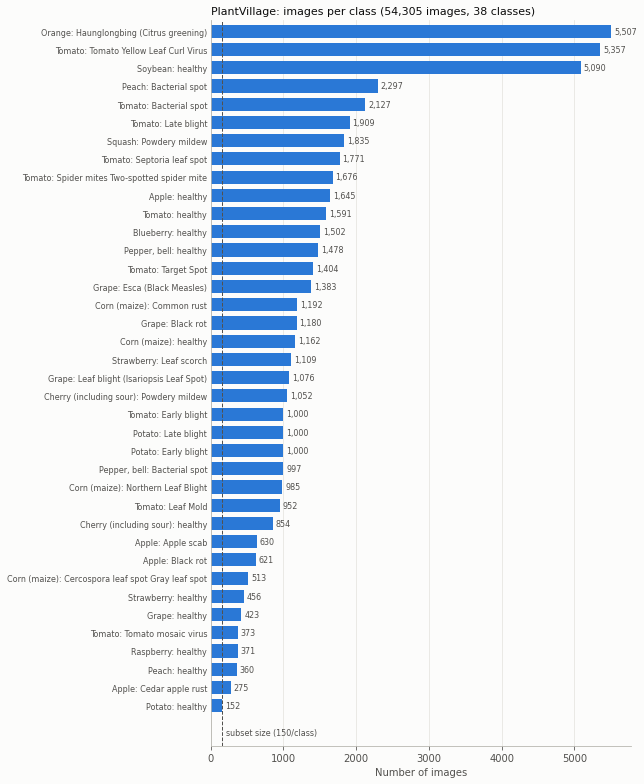

In [4]:
c_sorted = counts.sort_values()
fig, ax = plt.subplots(figsize=(9, 11))
bars = ax.barh([pretty(c) for c in c_sorted.index], c_sorted.values, color=BLUE, height=0.72)
for b, v in zip(bars, c_sorted.values):
    ax.text(v + 40, b.get_y() + b.get_height() / 2, f'{v:,}', va='center', fontsize=8, color=INK2)
if SUBSET:
    ax.axvline(SUBSET, color=INK2, lw=1, ls='--')
    ax.text(SUBSET + 60, -1.6, f'subset size ({SUBSET}/class)', fontsize=8, color=INK2)
ax.set_xlabel('Number of images')
ax.set_title(f'PlantVillage: images per class ({len(df_all):,} images, {NUM_CLASSES} classes)', loc='left')
ax.grid(axis='x'); ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=8, length=0)
ax.set_ylim(-2.2, len(c_sorted) - 0.4)
plt.tight_layout()
save_fig(fig, '02_images_per_class.png')
plt.show()

saved -> outputs/02_sample_grid.png


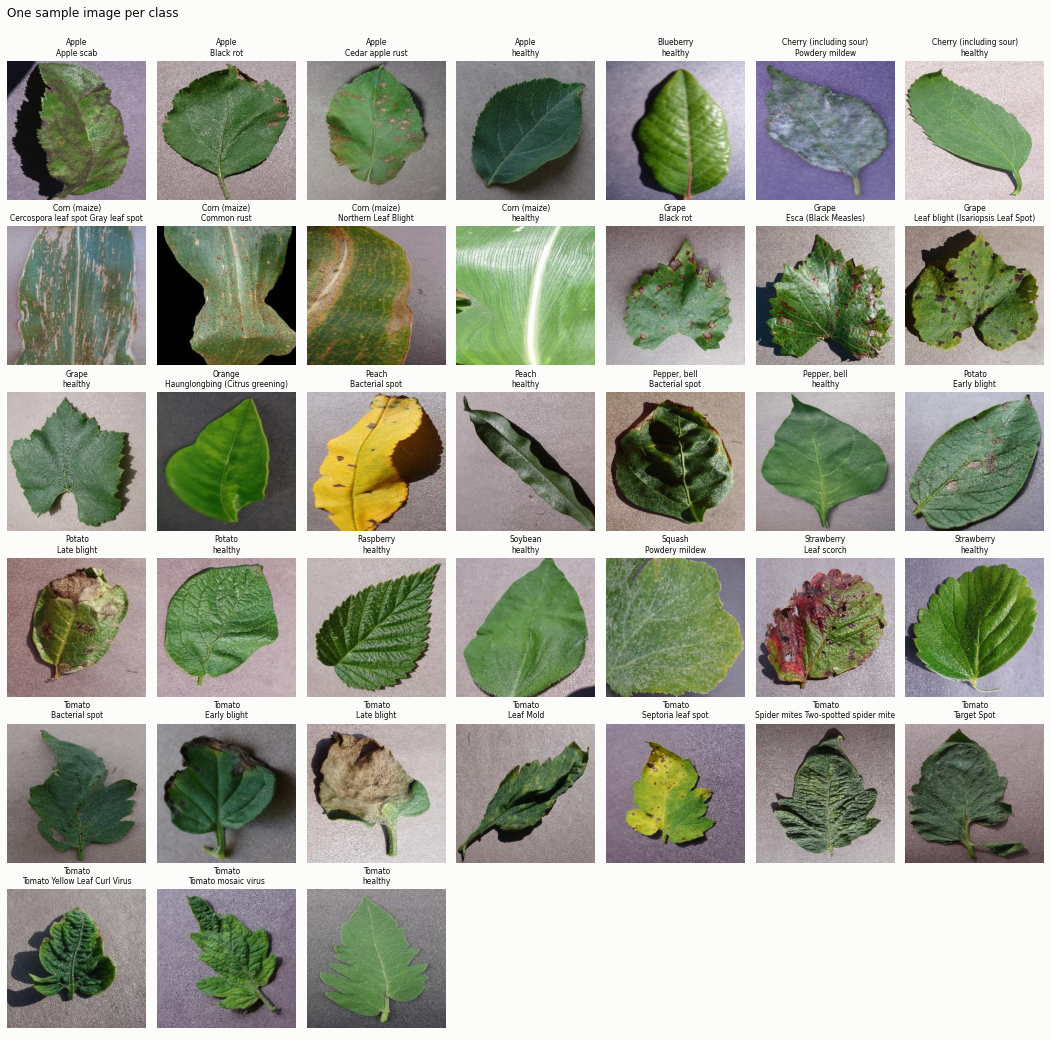

In [5]:
# One random sample per class
samples = df_all.groupby('label').sample(1, random_state=SEED).set_index('label').loc[class_names, 'path']
ncols = 7
nrows = int(np.ceil(NUM_CLASSES / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.1, nrows * 2.45))
for ax in axes.flat:
    ax.axis('off')
for ax, (c, p) in zip(axes.flat, samples.items()):
    ax.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
    crop, _, cond = pretty(c).partition(': ')
    ax.set_title(f'{crop}\n{cond}', fontsize=7.5)
fig.suptitle('One sample image per class', x=0.01, ha='left', fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.98))
save_fig(fig, '02_sample_grid.png')
plt.show()

### Working subset

The dataset is strongly imbalanced (see the ratio above). When `SUBSET` is set, we draw the same number of images
from every class with a fixed seed. This makes the classes balanced and keeps CPU training time manageable.
The smallest class has just over 150 images, so 150/class keeps every class at the same size.

In [6]:
if SUBSET:
    df = pd.concat([g.sample(n=min(len(g), SUBSET), random_state=SEED)
                    for _, g in df_all.groupby('label')]).reset_index(drop=True)
else:
    df = df_all.copy()
label_to_idx = {c: i for i, c in enumerate(class_names)}
df['y'] = df['label'].map(label_to_idx)
print(f'Working set: {len(df):,} images | per class min {df.label.value_counts().min()}, '
      f'max {df.label.value_counts().max()}')

Working set: 5,700 images | per class min 150, max 150


## 3. Image preprocessing

Classical image processing applied before the CNN. We use the same four example leaves for every step
(three diseased, one healthy), so each before/after figure is directly comparable.

| Step | Operation | Purpose |
|---|---|---|
| 3.1 | Resize to 260×260 | EfficientNetB2's native input resolution |
| 3.2 | CLAHE on the **L** channel of LAB | Enhance local contrast (lesion edges, texture) without shifting hue |
| 3.3 | Gaussian / median denoising | Suppress sensor noise and JPEG artefacts |
| 3.4 | HSV segmentation | Isolate the leaf, then the diseased (yellow/brown/necrotic) regions |

In [7]:
def load_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def resize(img, size=IMG_SIZE):
    interp = cv2.INTER_AREA if img.shape[0] > size else cv2.INTER_CUBIC
    return cv2.resize(img, (size, size), interpolation=interp)

def apply_clahe(img, clip=2.0, tiles=8):
    # Contrast Limited Adaptive Histogram Equalisation on the lightness channel only (colour preserved)
    l, a, b = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2LAB))
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tiles, tiles)).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

def denoise(img, method='median', k=3):
    if method == 'gaussian':
        return cv2.GaussianBlur(img, (k, k), 0)
    return cv2.medianBlur(img, k)

def preprocess(img, enhance=True):
    # Pipeline used for model inputs: resize -> (CLAHE -> median denoise). Output uint8 RGB in 0-255.
    img = resize(img)
    if enhance:
        img = denoise(apply_clahe(img), 'median', 3)
    return img

# Example leaves: three diseased classes + one healthy class (fixed seed)
EXAMPLE_CLASSES = ['Tomato___Early_blight', 'Potato___Late_blight', 'Grape___Black_rot', 'Potato___healthy']
examples = [(c, df[df.label == c].sample(1, random_state=SEED)['path'].iloc[0]) for c in EXAMPLE_CLASSES]
originals = [load_rgb(p) for _, p in examples]
for (c, p), im in zip(examples, originals):
    print(f'{pretty(c):28s} {im.shape}  {p}')

Tomato: Early blight         (256, 256, 3)  data/PlantVillage-Dataset/raw/color/Tomato___Early_blight/bbcccb3c-bcf2-4dc9-b2e2-6aecd86f52d5___RS_Erly.B 8370.JPG
Potato: Late blight          (256, 256, 3)  data/PlantVillage-Dataset/raw/color/Potato___Late_blight/c1389cbc-d327-478b-92b3-550c3210ed5a___RS_LB 4025.JPG
Grape: Black rot             (256, 256, 3)  data/PlantVillage-Dataset/raw/color/Grape___Black_rot/2b6ed613-e216-43ac-b518-ee54873b21e3___FAM_B.Rot 0639.JPG
Potato: healthy              (256, 256, 3)  data/PlantVillage-Dataset/raw/color/Potato___healthy/bb328d40-e4e6-4b84-a92a-e7cb3922c19d___RS_HL 1829.JPG


### 3.1 Resizing

PlantVillage images are 256×256. EfficientNetB2 was designed for 260×260 inputs, so we resize to that
(bicubic interpolation when enlarging, area interpolation when shrinking). The visual change is minimal, which is
what we want: the leaf is not distorted.

saved -> outputs/03_1_resize.png


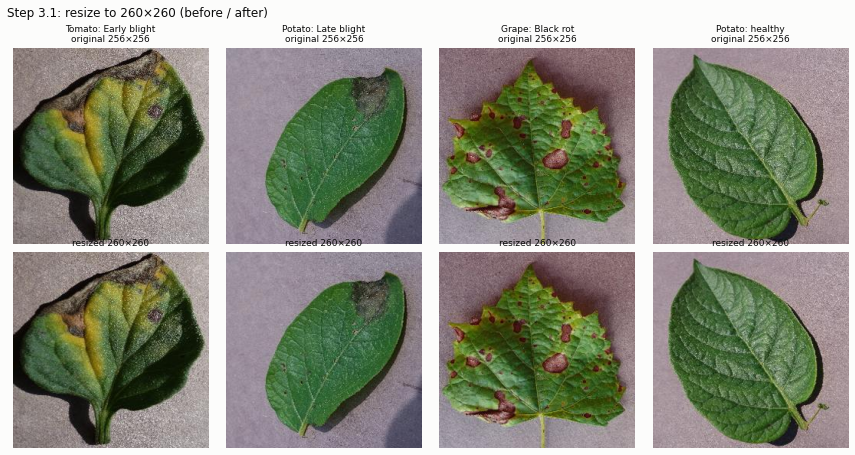

In [8]:
resized = [resize(im) for im in originals]
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4))
for j, ((c, _), o, r) in enumerate(zip(examples, originals, resized)):
    axes[0, j].imshow(o); axes[0, j].set_title(f'{pretty(c)}\noriginal {o.shape[1]}×{o.shape[0]}', fontsize=9)
    axes[1, j].imshow(r); axes[1, j].set_title(f'resized {r.shape[1]}×{r.shape[0]}', fontsize=9)
for ax in axes.flat: ax.axis('off')
fig.suptitle('Step 3.1: resize to 260×260 (before / after)', x=0.01, ha='left', fontsize=12)
plt.tight_layout()
save_fig(fig, '03_1_resize.png')
plt.show()

### 3.2 CLAHE on the L channel (LAB colour space)

Plain histogram equalisation on RGB distorts colours, and colour is a key disease cue. We convert to **LAB**,
apply **CLAHE** (clip limit 2.0, 8×8 tiles) only to the **L** (lightness) channel, and convert back. The
histograms show the L channel being spread over a wider range, and lesion boundaries become more distinct.

saved -> outputs/03_2_clahe.png


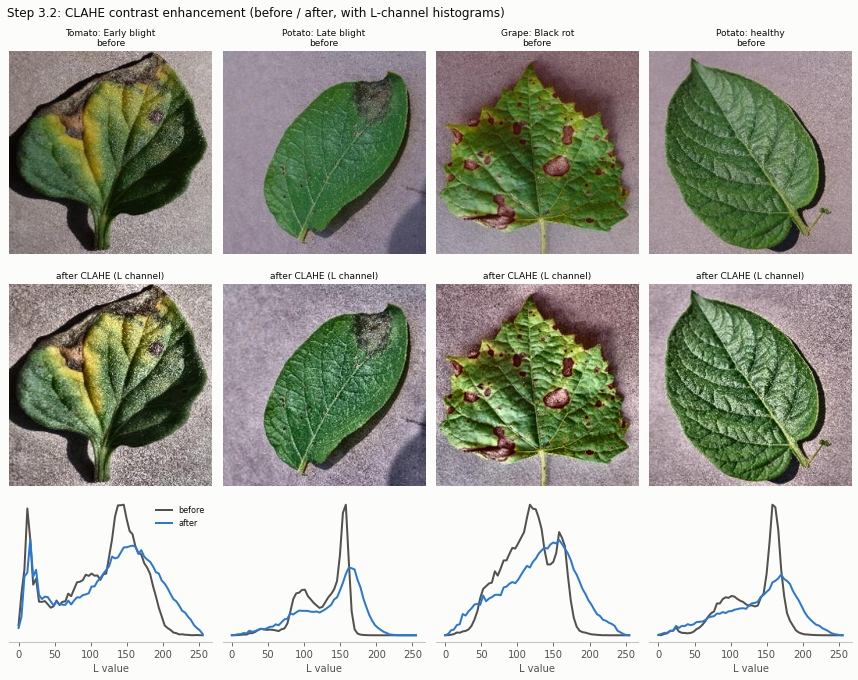

Tomato: Early blight         L std (global contrast):  55.1 ->  62.9
Potato: Late blight          L std (global contrast):  31.7 ->  41.2
Grape: Black rot             L std (global contrast):  35.2 ->  49.0
Potato: healthy              L std (global contrast):  37.1 ->  48.9


In [9]:
clahe_imgs = [apply_clahe(r) for r in resized]
fig, axes = plt.subplots(3, 4, figsize=(12, 9.6), gridspec_kw={'height_ratios': [1, 1, 0.6]})
for j, ((c, _), r, e) in enumerate(zip(examples, resized, clahe_imgs)):
    axes[0, j].imshow(r); axes[0, j].set_title(f'{pretty(c)}\nbefore', fontsize=9)
    axes[1, j].imshow(e); axes[1, j].set_title('after CLAHE (L channel)', fontsize=9)
    axes[0, j].axis('off'); axes[1, j].axis('off')
    for im, col, lab in [(r, INK2, 'before'), (e, BLUE, 'after')]:
        L = cv2.cvtColor(im, cv2.COLOR_RGB2LAB)[..., 0]
        h = cv2.calcHist([L], [0], None, [64], [0, 256]).ravel()
        axes[2, j].plot(np.linspace(0, 255, 64), h / h.sum(), color=col, lw=2, label=lab)
    axes[2, j].set_xlabel('L value'); axes[2, j].set_yticks([])
    axes[2, j].spines['left'].set_visible(False)
axes[2, 0].legend(frameon=False, fontsize=8)
fig.suptitle('Step 3.2: CLAHE contrast enhancement (before / after, with L-channel histograms)',
             x=0.01, ha='left', fontsize=12)
plt.tight_layout()
save_fig(fig, '03_2_clahe.png')
plt.show()

for (c, _), r, e in zip(examples, resized, clahe_imgs):
    Lr = cv2.cvtColor(r, cv2.COLOR_RGB2LAB)[..., 0]; Le = cv2.cvtColor(e, cv2.COLOR_RGB2LAB)[..., 0]
    print(f'{pretty(c):28s} L std (global contrast): {Lr.std():5.1f} -> {Le.std():5.1f}')

### 3.3 Denoising: Gaussian vs. median

Both filters use a 3×3 kernel. The **Gaussian** filter averages neighbouring pixels and blurs edges uniformly. The
**median** filter replaces each pixel with the neighbourhood median, which removes impulse noise and JPEG speckle
while keeping edges, such as lesion boundaries, sharp. The zoomed 70×70 crops (bottom row of each pair) show the
difference. We also measure sharpness as the variance of the Laplacian: lower means smoother.

The model pipeline uses **CLAHE followed by a 3×3 median filter**.

saved -> outputs/03_3_denoise.png


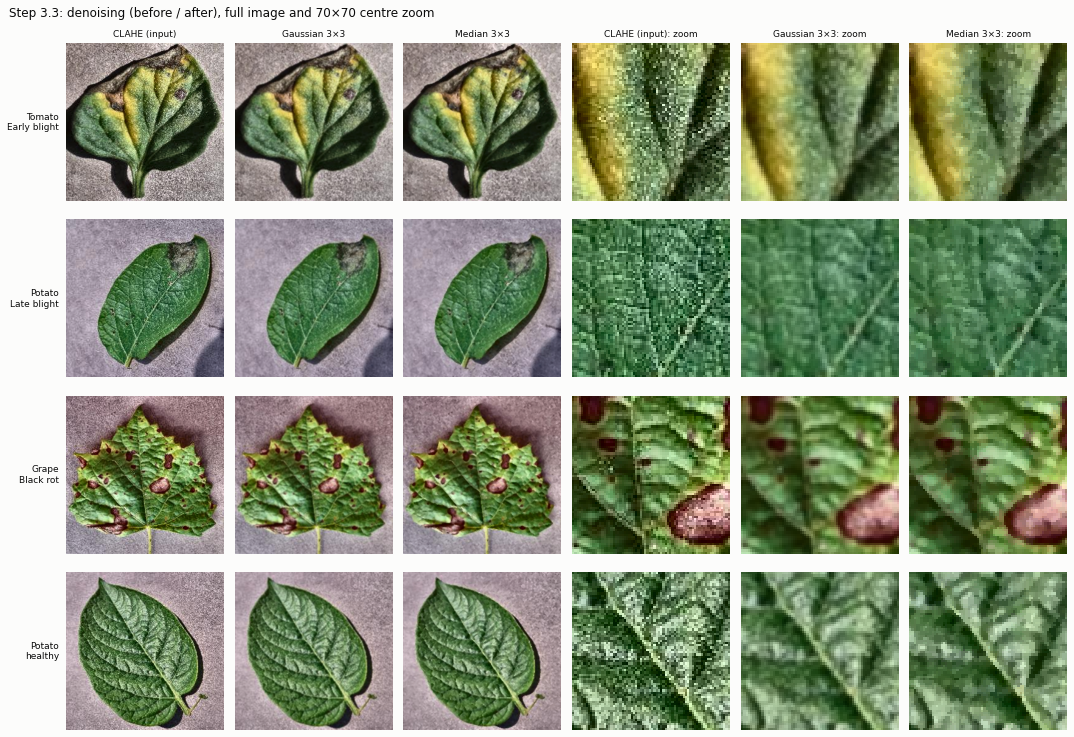

                        CLAHE  Gaussian 3x3  Median 3x3
Laplacian variance                                     
Tomato: Early blight  11300.0         520.0      1141.0
Potato: Late blight    5352.0         328.0       654.0
Grape: Black rot       4932.0         416.0       902.0
Potato: healthy        9998.0         553.0      1273.0


In [10]:
gauss_imgs = [denoise(e, 'gaussian', 3) for e in clahe_imgs]
median_imgs = [denoise(e, 'median', 3) for e in clahe_imgs]

def crop_center(im, s=70):
    h, w = im.shape[:2]; y, x = (h - s) // 2, (w - s) // 2
    return im[y:y + s, x:x + s]

fig, axes = plt.subplots(4, 6, figsize=(15, 10.5))
titles = ['CLAHE (input)', 'Gaussian 3×3', 'Median 3×3']
for i, ((c, _), e, g, m) in enumerate(zip(examples, clahe_imgs, gauss_imgs, median_imgs)):
    for j, (im, t) in enumerate(zip([e, g, m], titles)):
        axes[i, j].imshow(im); axes[i, j].set_title(t if i == 0 else '', fontsize=9)
        axes[i, j + 3].imshow(crop_center(im), interpolation='nearest')
        axes[i, j + 3].set_title(f'{t}: zoom' if i == 0 else '', fontsize=9)
    axes[i, 0].text(-12, 130, pretty(c).replace(': ', '\n'), ha='right', va='center', fontsize=9)
for ax in axes.flat: ax.axis('off')
fig.suptitle('Step 3.3: denoising (before / after), full image and 70×70 centre zoom', x=0.01, ha='left', fontsize=12)
plt.tight_layout()
save_fig(fig, '03_3_denoise.png')
plt.show()

lap = lambda im: cv2.Laplacian(cv2.cvtColor(im, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var()
print(pd.DataFrame({'CLAHE': [lap(e) for e in clahe_imgs], 'Gaussian 3x3': [lap(g) for g in gauss_imgs],
                    'Median 3x3': [lap(m) for m in median_imgs]},
                   index=[pretty(c) for c, _ in examples]).round(0).rename_axis('Laplacian variance'))

### 3.4 HSV-based segmentation of diseased regions

Segmentation runs on the enhanced (CLAHE + median) image in HSV space (OpenCV ranges: H 0-179, S/V 0-255):

1. **Leaf mask.** Plant tissue has hue between yellow-brown and green (H 5-95) and some saturation (S ≥ 40,
   V ≥ 30). PlantVillage backgrounds are grey/blue-violet and fall outside this range. A morphological close/open
   cleans the mask, and the leaf contours are filled so dark lesions *inside* the leaf are kept. The mask is then
   eroded by 5 px so the dark cast-shadow rim along the leaf edge is not counted as disease.
2. **Diseased mask (inside the leaf only).** Pixels that are **yellow/brown/reddish-brown** (H ≤ 30 or H ≥ 150,
   S ≥ 60: chlorosis, blight and rot lesions) or **very dark** (V < 45: necrotic tissue). Healthy green tissue (H ≈ 35-90) is excluded.
3. **Severity** = diseased pixels / leaf pixels.

This is a transparent, rule-based baseline for *localising* symptoms. It is shown for interpretability and is
**not** used as a model input (the CNN receives the full enhanced image). Known limitations: white or grey symptoms
(powdery mildew, some late-blight lesions) are not captured, and lesions right at the leaf margin are partly removed
by the erosion. Adding a low-saturation "grey lesion" rule was tried while tuning and reduced the healthy-vs-diseased
separation, so it was left out.

saved -> outputs/03_4_hsv_segmentation.png


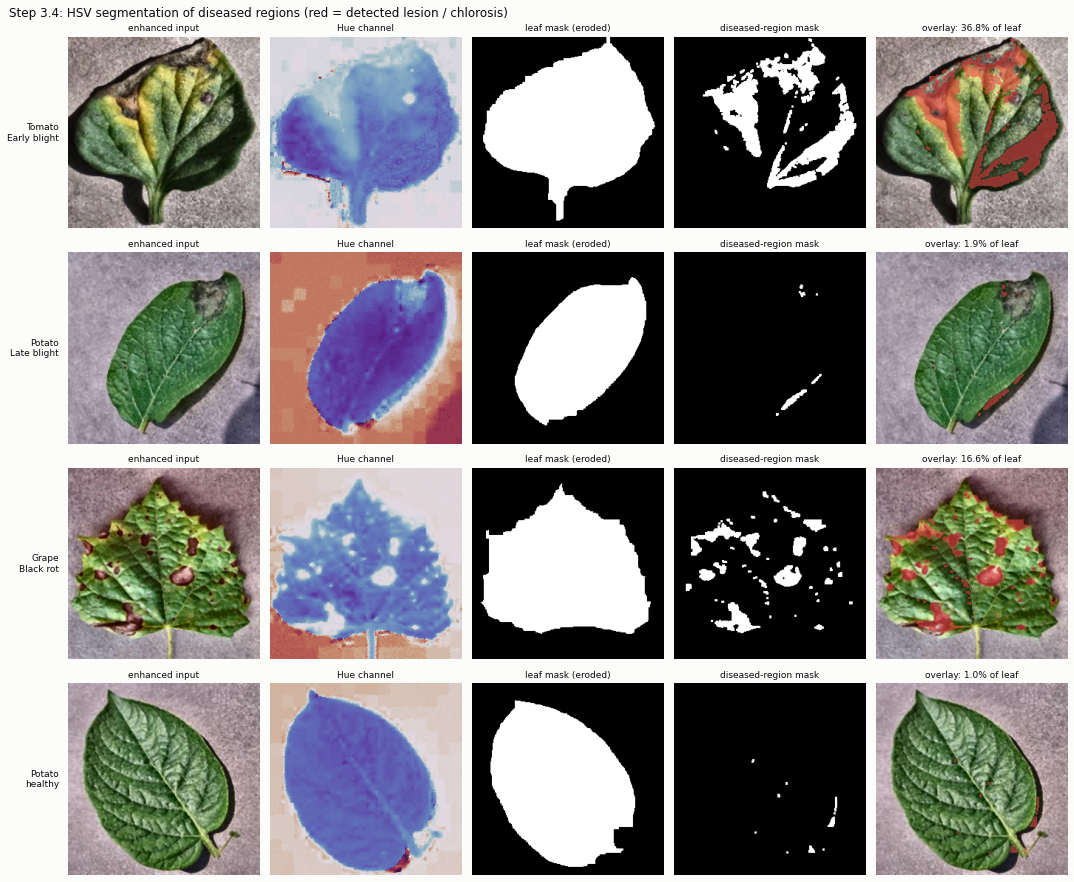

In [11]:
def segment_disease(img_rgb):
    h, s, v = cv2.split(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV))
    leaf = ((h >= 5) & (h <= 95) & (s >= 40) & (v >= 30)).astype(np.uint8) * 255
    leaf = cv2.morphologyEx(leaf, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    leaf = cv2.morphologyEx(leaf, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    contours, _ = cv2.findContours(leaf, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    leaf_mask = np.zeros_like(leaf)
    cv2.drawContours(leaf_mask, [c for c in contours if cv2.contourArea(c) > 0.02 * leaf.size], -1, 255, -1)
    leaf_mask = cv2.erode(leaf_mask, np.ones((11, 11), np.uint8))   # drop the cast-shadow rim at the leaf edge

    brown = ((h <= 30) | (h >= 150)) & (s >= 60) & (v >= 40)
    dark = v < 45
    disease = ((brown | dark) & (leaf_mask > 0)).astype(np.uint8) * 255
    disease = cv2.morphologyEx(disease, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    severity = disease.sum() / max(leaf_mask.sum(), 1)
    return leaf_mask, disease, severity

def overlay(img, mask, color=(227, 73, 72), alpha=0.6):
    out = img.copy().astype(np.float32)
    out[mask > 0] = (1 - alpha) * out[mask > 0] + alpha * np.array(color, np.float32)
    return out.astype(np.uint8)

enhanced = median_imgs
fig, axes = plt.subplots(4, 5, figsize=(15, 12.5))
for i, ((c, _), e) in enumerate(zip(examples, enhanced)):
    leaf_mask, dis, sev = segment_disease(e)
    hsv = cv2.cvtColor(e, cv2.COLOR_RGB2HSV)
    panels = [(e, 'enhanced input', None), (hsv[..., 0], 'Hue channel', 'twilight'),
              (leaf_mask, 'leaf mask (eroded)', 'gray'), (dis, 'diseased-region mask', 'gray'),
              (overlay(e, dis), f'overlay: {sev:.1%} of leaf', None)]
    for j, (im, t, cmap) in enumerate(panels):
        axes[i, j].imshow(im, cmap=cmap, vmin=0 if cmap else None, vmax=(179 if cmap == 'twilight' else 255) if cmap else None)
        axes[i, j].set_title(t, fontsize=9); axes[i, j].axis('off')
    axes[i, 0].text(-12, 130, pretty(c).replace(': ', '\n'), ha='right', va='center', fontsize=9)
fig.suptitle('Step 3.4: HSV segmentation of diseased regions (red = detected lesion / chlorosis)',
             x=0.01, ha='left', fontsize=12)
plt.tight_layout()
save_fig(fig, '03_4_hsv_segmentation.png')
plt.show()

**Sanity check on the whole working set.** If the segmentation captures disease symptoms, healthy leaves should
have a much lower estimated severity than diseased leaves. We run it on every image in the working set and measure
how well severity alone separates diseased from healthy leaves (ROC AUC: 0.5 = chance, 1.0 = perfect).

Segmented 5,700 images in 10.3s
             count   mean    25%    50%    75%
is_healthy                                    
diseased    3900.0  0.131  0.025  0.069  0.160
healthy     1800.0  0.028  0.002  0.010  0.033
ROC AUC (severity as a diseased-vs-healthy score): 0.799


saved -> outputs/03_5_segmentation_severity_check.png


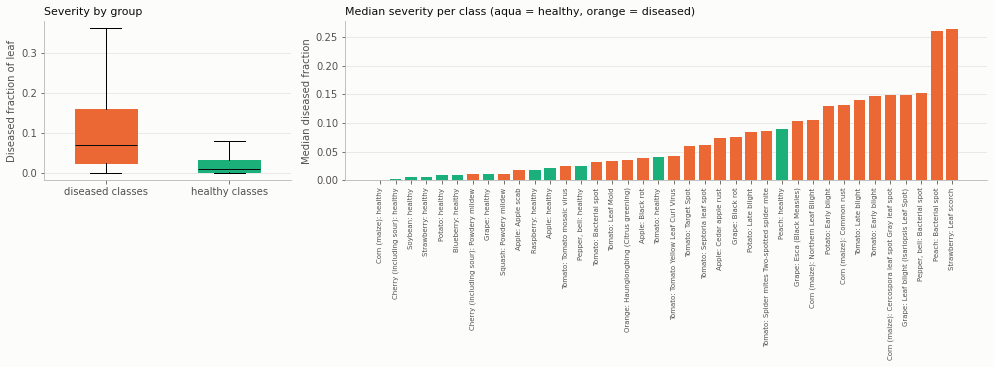

In [12]:
t0 = time.time()
sev = np.array([segment_disease(preprocess(load_rgb(p)))[2] for p in df['path']])
df['severity'] = sev
df['is_healthy'] = df['label'].str.endswith('healthy')
print(f'Segmented {len(df):,} images in {time.time() - t0:.1f}s')
summary = df.groupby('is_healthy')['severity'].describe()[['count', 'mean', '25%', '50%', '75%']]
summary.index = summary.index.map({True: 'healthy', False: 'diseased'})
print(summary.round(3))
from sklearn.metrics import roc_auc_score
print(f'ROC AUC (severity as a diseased-vs-healthy score): {roc_auc_score(~df.is_healthy, df.severity):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1, 2.6]})
groups = [df.loc[~df.is_healthy, 'severity'], df.loc[df.is_healthy, 'severity']]
bp = axes[0].boxplot(groups, tick_labels=['diseased classes', 'healthy classes'], patch_artist=True,
                     widths=0.5, showfliers=False, medianprops={'color': INK})
for patch, col in zip(bp['boxes'], [ORANGE, AQUA]):
    patch.set_facecolor(col); patch.set_edgecolor(col)
axes[0].set_ylabel('Diseased fraction of leaf')
axes[0].set_title('Severity by group', loc='left'); axes[0].grid(axis='y'); axes[0].set_axisbelow(True)

per_class = df.groupby('label')['severity'].median().sort_values()
cols = [AQUA if c.endswith('healthy') else ORANGE for c in per_class.index]
axes[1].bar(range(len(per_class)), per_class.values, color=cols, width=0.75)
axes[1].set_xticks(range(len(per_class)))
axes[1].set_xticklabels([pretty(c) for c in per_class.index], rotation=90, fontsize=7)
axes[1].set_ylabel('Median diseased fraction')
axes[1].set_title('Median severity per class (aqua = healthy, orange = diseased)', loc='left')
axes[1].grid(axis='y'); axes[1].set_axisbelow(True)
plt.tight_layout()
save_fig(fig, '03_5_segmentation_severity_check.png')
plt.show()

### Preprocessing summary

The final preprocessing function `preprocess(img, enhance=True)` (resize → CLAHE on L → 3×3 median filter) is
used for the model inputs in the following sections. `enhance=False` (resize only) is the baseline for the
ablation study in Section 9.

saved -> outputs/03_6_pipeline_before_after.png


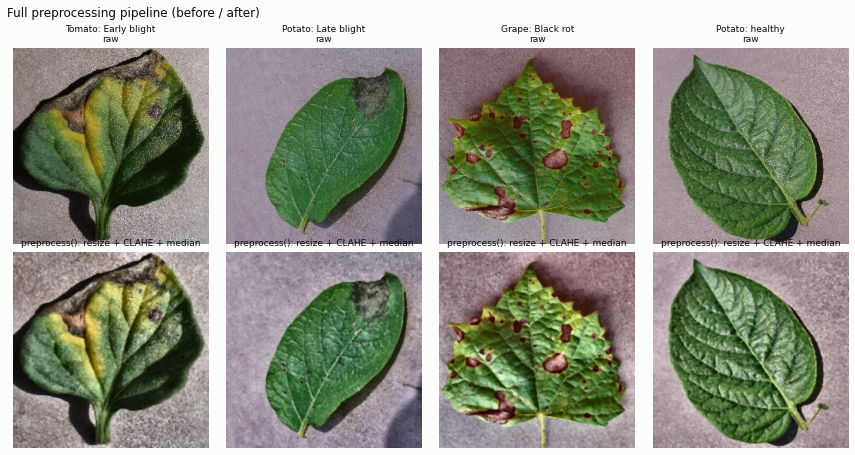

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4))
for j, ((c, _), o) in enumerate(zip(examples, originals)):
    axes[0, j].imshow(o); axes[0, j].set_title(f'{pretty(c)}\nraw', fontsize=9)
    axes[1, j].imshow(preprocess(o)); axes[1, j].set_title('preprocess(): resize + CLAHE + median', fontsize=9)
for ax in axes.flat: ax.axis('off')
fig.suptitle('Full preprocessing pipeline (before / after)', x=0.01, ha='left', fontsize=12)
plt.tight_layout()
save_fig(fig, '03_6_pipeline_before_after.png')
plt.show()